# Grid Inspection

Takes a folder of saved backtest results -- one subdirectory per UID, each
written by `runners/run_futures_strats.py` / `runners/run_futures_grid.py`
(`tradebook.csv`, `equity.csv`, `metrics.csv`) -- and gives you:

1. A metrics comparison table across every UID in that folder.
2. The same comparison recomputed under a simulated per-execution slippage
   cost, so you can see how sensitive each parameter combo is to slippage
   before trusting the no-slippage backtest numbers.
3. An equity-curve chart with every UID overlaid, both with and without
   slippage applied.

Point `RESULTS_DIR` (in the Config cell) at whatever grid you want to
inspect -- e.g. the STEMA sweep at `results/futures/stema`.

In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from analytics.metrics import calculate_metrics
from strategies.futures.instruments import get_futures_instrument

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 220)

print("Setup OK")

Setup OK


## Config

`RESULTS_DIR` is any folder containing one subdirectory per UID (each with
`tradebook.csv` / `equity.csv` / `metrics.csv` inside) -- point it at a
single strategy's results folder (e.g. a whole grid sweep) or anywhere
else with that same layout.

`SLIPPAGE_TICKS` drives the simulated-slippage comparison: every trade
execution (each entry and each exit counts separately, so a full round
trip pays it twice) is assumed to fill `SLIPPAGE_TICKS` ticks worse than
the backtest's recorded fill price. Set it to `0` to make the "slippage"
scenario identical to the raw one.

In [2]:
# Folder containing one subdirectory per UID -- e.g. the STEMA grid sweep
# from runners/run_futures_grid.py.
RESULTS_DIR = PROJECT_ROOT / "results" / "futures" / "stema"

# Ticks of adverse price movement assumed on every execution (fill worse
# than the backtest recorded). Applied to both entries and exits.
SLIPPAGE_TICKS = 1.0

# Must match what runners/run_futures_strats.py used when it produced the
# saved metrics.csv/equity.csv (see its save_and_print_results call) so
# the recomputed metrics here stay comparable to the saved ones.
PERIODS_PER_YEAR = 252

print(f"Results dir:    {RESULTS_DIR}")
print(f"Slippage ticks: {SLIPPAGE_TICKS}")
print(f"Exists:         {RESULTS_DIR.exists()}")

Results dir:    /Users/mayankjain/Quant/atlas/results/futures/stema
Slippage ticks: 1.0
Exists:         True


## Metrics comparison

Loads every UID subdirectory under `RESULTS_DIR`, recomputes metrics from
the saved `equity.csv` both as-is and with `SLIPPAGE_TICKS` of simulated
slippage deducted at each execution, and lays them out as one table --
UIDs (plus a no-slippage/slippage scenario tag) on the rows, metrics on
the columns.

Slippage is applied as a running dollar cost (`SLIPPAGE_TICKS * tick_value`
per execution, from `strategies/futures/instruments.py`) subtracted from
the equity curve from each execution's timestamp onward -- so drawdown and
Sharpe see the drag when it actually happened, not just as a haircut on
the final number. Metrics are recomputed with `analytics.metrics.calculate_metrics`,
the same function `runners/reporting.py` uses to build the saved
`metrics.csv` files, so the no-slippage row here should match them.

In [3]:
_METRIC_COLUMNS = {
    "initial_equity", "final_equity", "total_return", "cagr",
    "annualized_volatility", "sharpe_ratio", "sortino_ratio", "max_drawdown",
    "calmar_ratio", "max_drawdown_duration_days", "win_rate", "best_day",
    "worst_day", "positive_days", "negative_days", "flat_days", "elapsed_years",
}
_BOOKKEEPING_COLUMNS = {"uid", "strategy", "trade_count"}


def _discover_uid_dirs(results_dir: Path) -> list[Path]:
    """Every immediate subdirectory that looks like a saved backtest run."""
    return sorted(
        path for path in results_dir.iterdir()
        if path.is_dir() and (path / "equity.csv").exists()
    )


def apply_slippage(
    equity: pd.DataFrame,
    tradebook: pd.DataFrame,
    tick_value: float,
    slippage_ticks: float,
) -> pd.DataFrame:
    """Deduct a per-execution slippage cost from the equity curve, applied
    cumulatively from each execution's timestamp forward."""
    adjusted = equity.copy()
    adjusted["timestamp"] = pd.to_datetime(adjusted["timestamp"])
    adjusted = adjusted.sort_values("timestamp")

    if slippage_ticks <= 0 or tradebook.empty:
        return adjusted

    executions = tradebook[["timestamp"]].copy()
    executions["timestamp"] = pd.to_datetime(executions["timestamp"])
    executions = executions.sort_values("timestamp")
    executions["cumulative_cost"] = (
        np.arange(1, len(executions) + 1) * slippage_ticks * tick_value
    )

    adjusted = pd.merge_asof(
        adjusted,
        executions[["timestamp", "cumulative_cost"]],
        on="timestamp",
        direction="backward",
    )
    adjusted["cumulative_cost"] = adjusted["cumulative_cost"].fillna(0.0)
    adjusted["equity"] = adjusted["equity"] - adjusted["cumulative_cost"]
    return adjusted.drop(columns=["cumulative_cost"])


records = []
equity_curves: dict[str, dict[str, pd.DataFrame]] = {}

for uid_dir in _discover_uid_dirs(RESULTS_DIR):
    uid = uid_dir.name
    equity = pd.read_csv(uid_dir / "equity.csv")
    tradebook = pd.read_csv(uid_dir / "tradebook.csv")
    metrics_row = pd.read_csv(uid_dir / "metrics.csv").iloc[0]

    instrument = get_futures_instrument(metrics_row["symbol"])
    param_columns = {
        col: metrics_row[col]
        for col in metrics_row.index
        if col not in _METRIC_COLUMNS and col not in _BOOKKEEPING_COLUMNS
    }

    raw_equity = equity.copy()
    raw_equity["timestamp"] = pd.to_datetime(raw_equity["timestamp"])
    slipped_equity = apply_slippage(
        equity, tradebook, instrument.tick_value, SLIPPAGE_TICKS,
    )

    equity_curves[uid] = {"no_slippage": raw_equity, "slippage": slipped_equity}

    for scenario, curve in (
        ("no_slippage", raw_equity),
        (f"slippage_{SLIPPAGE_TICKS:g}_ticks", slipped_equity),
    ):
        metrics = calculate_metrics(curve, periods_per_year=PERIODS_PER_YEAR)
        records.append({
            "uid": uid,
            "scenario": scenario,
            "trades": len(tradebook),
            **param_columns,
            **metrics,
        })

comparison = pd.DataFrame(records).set_index(["uid", "scenario"])

print(f"Loaded {len(equity_curves)} UIDs from {RESULTS_DIR}")

display_columns = [
    c for c in (
        list(param_columns.keys()) + [
            "trades", "final_equity", "total_return", "cagr",
            "annualized_volatility", "sharpe_ratio", "sortino_ratio",
            "max_drawdown", "calmar_ratio", "win_rate",
        ]
    )
    if c in comparison.columns
]

comparison[display_columns].sort_values(
    ["scenario", "sharpe_ratio"], ascending=[True, False],
)

Loaded 27 UIDs from /Users/mayankjain/Quant/atlas/results/futures/stema


,,strategy_type,symbol,data_symbol,root_symbol,multiplier,atr_period,stop_atr_multiple,supertrend_period,supertrend_multiplier,ema_period,trades,final_equity,total_return,cagr,annualized_volatility,sharpe_ratio,sortino_ratio,max_drawdown,calmar_ratio,win_rate
uid,scenario,,,,,,,,,,,,,,,,,,,,
stema__s=MES__st_period=7__st_mult=3__ema=100__atr=14__sl_atr=10,no_slippage,stema,MES,MES=F,ES,5.0,14,10.0,7,3.0,100,271,20180.000000,1.018000,0.144993,0.046840,0.147172,0.060661,-0.250987,0.577690,0.505745
stema__s=MES__st_period=10__st_mult=3__ema=100__atr=14__sl_atr=10,no_slippage,stema,MES,MES=F,ES,5.0,14,10.0,10,3.0,100,281,19501.250000,0.950125,0.137463,0.047849,0.139094,0.058113,-0.244974,0.561134,0.507678
stema__s=MES__st_period=14__st_mult=3__ema=100__atr=14__sl_atr=10,no_slippage,stema,MES,MES=F,ES,5.0,14,10.0,14,3.0,100,275,18408.585769,0.840859,0.124885,0.047678,0.129433,0.053294,-0.228087,0.547532,0.508009
stema__s=MES__st_period=7__st_mult=3__ema=50__atr=14__sl_atr=10,no_slippage,stema,MES,MES=F,ES,5.0,14,10.0,7,3.0,50,389,17545.595890,0.754560,0.114517,0.051735,0.115600,0.055594,-0.272367,0.420452,0.501828
stema__s=MES__st_period=7__st_mult=3__ema=200__atr=14__sl_atr=10,no_slippage,stema,MES,MES=F,ES,5.0,14,10.0,7,3.0,200,225,15090.000000,0.509000,0.082579,0.041862,0.102148,0.036694,-0.253760,0.325420,0.515340
stema__s=MES__st_period=14__st_mult=3__ema=200__atr=14__sl_atr=10,no_slippage,stema,MES,MES=F,ES,5.0,14,10.0,14,3.0,200,225,14625.000000,0.462500,0.076064,0.040466,0.097719,0.036134,-0.262807,0.289429,0.516603
stema__s=MES__st_period=14__st_mult=3__ema=50__atr=14__sl_atr=10,no_slippage,stema,MES,MES=F,ES,5.0,14,10.0,14,3.0,50,359,14697.696664,0.469770,0.077093,0.055399,0.085077,0.039759,-0.317438,0.242861,0.502394
stema__s=MES__st_period=10__st_mult=3__ema=50__atr=14__sl_atr=10,no_slippage,stema,MES,MES=F,ES,5.0,14,10.0,10,3.0,50,375,14263.002107,0.426300,0.070875,0.058999,0.079185,0.037608,-0.388565,0.182403,0.503238
stema__s=MES__st_period=10__st_mult=3__ema=200__atr=14__sl_atr=10,no_slippage,stema,MES,MES=F,ES,5.0,14,10.0,10,3.0,200,229,13116.250000,0.311625,0.053705,0.041917,0.074338,0.027206,-0.314307,0.170868,0.517474


## Equity curves -- all UIDs, with and without slippage

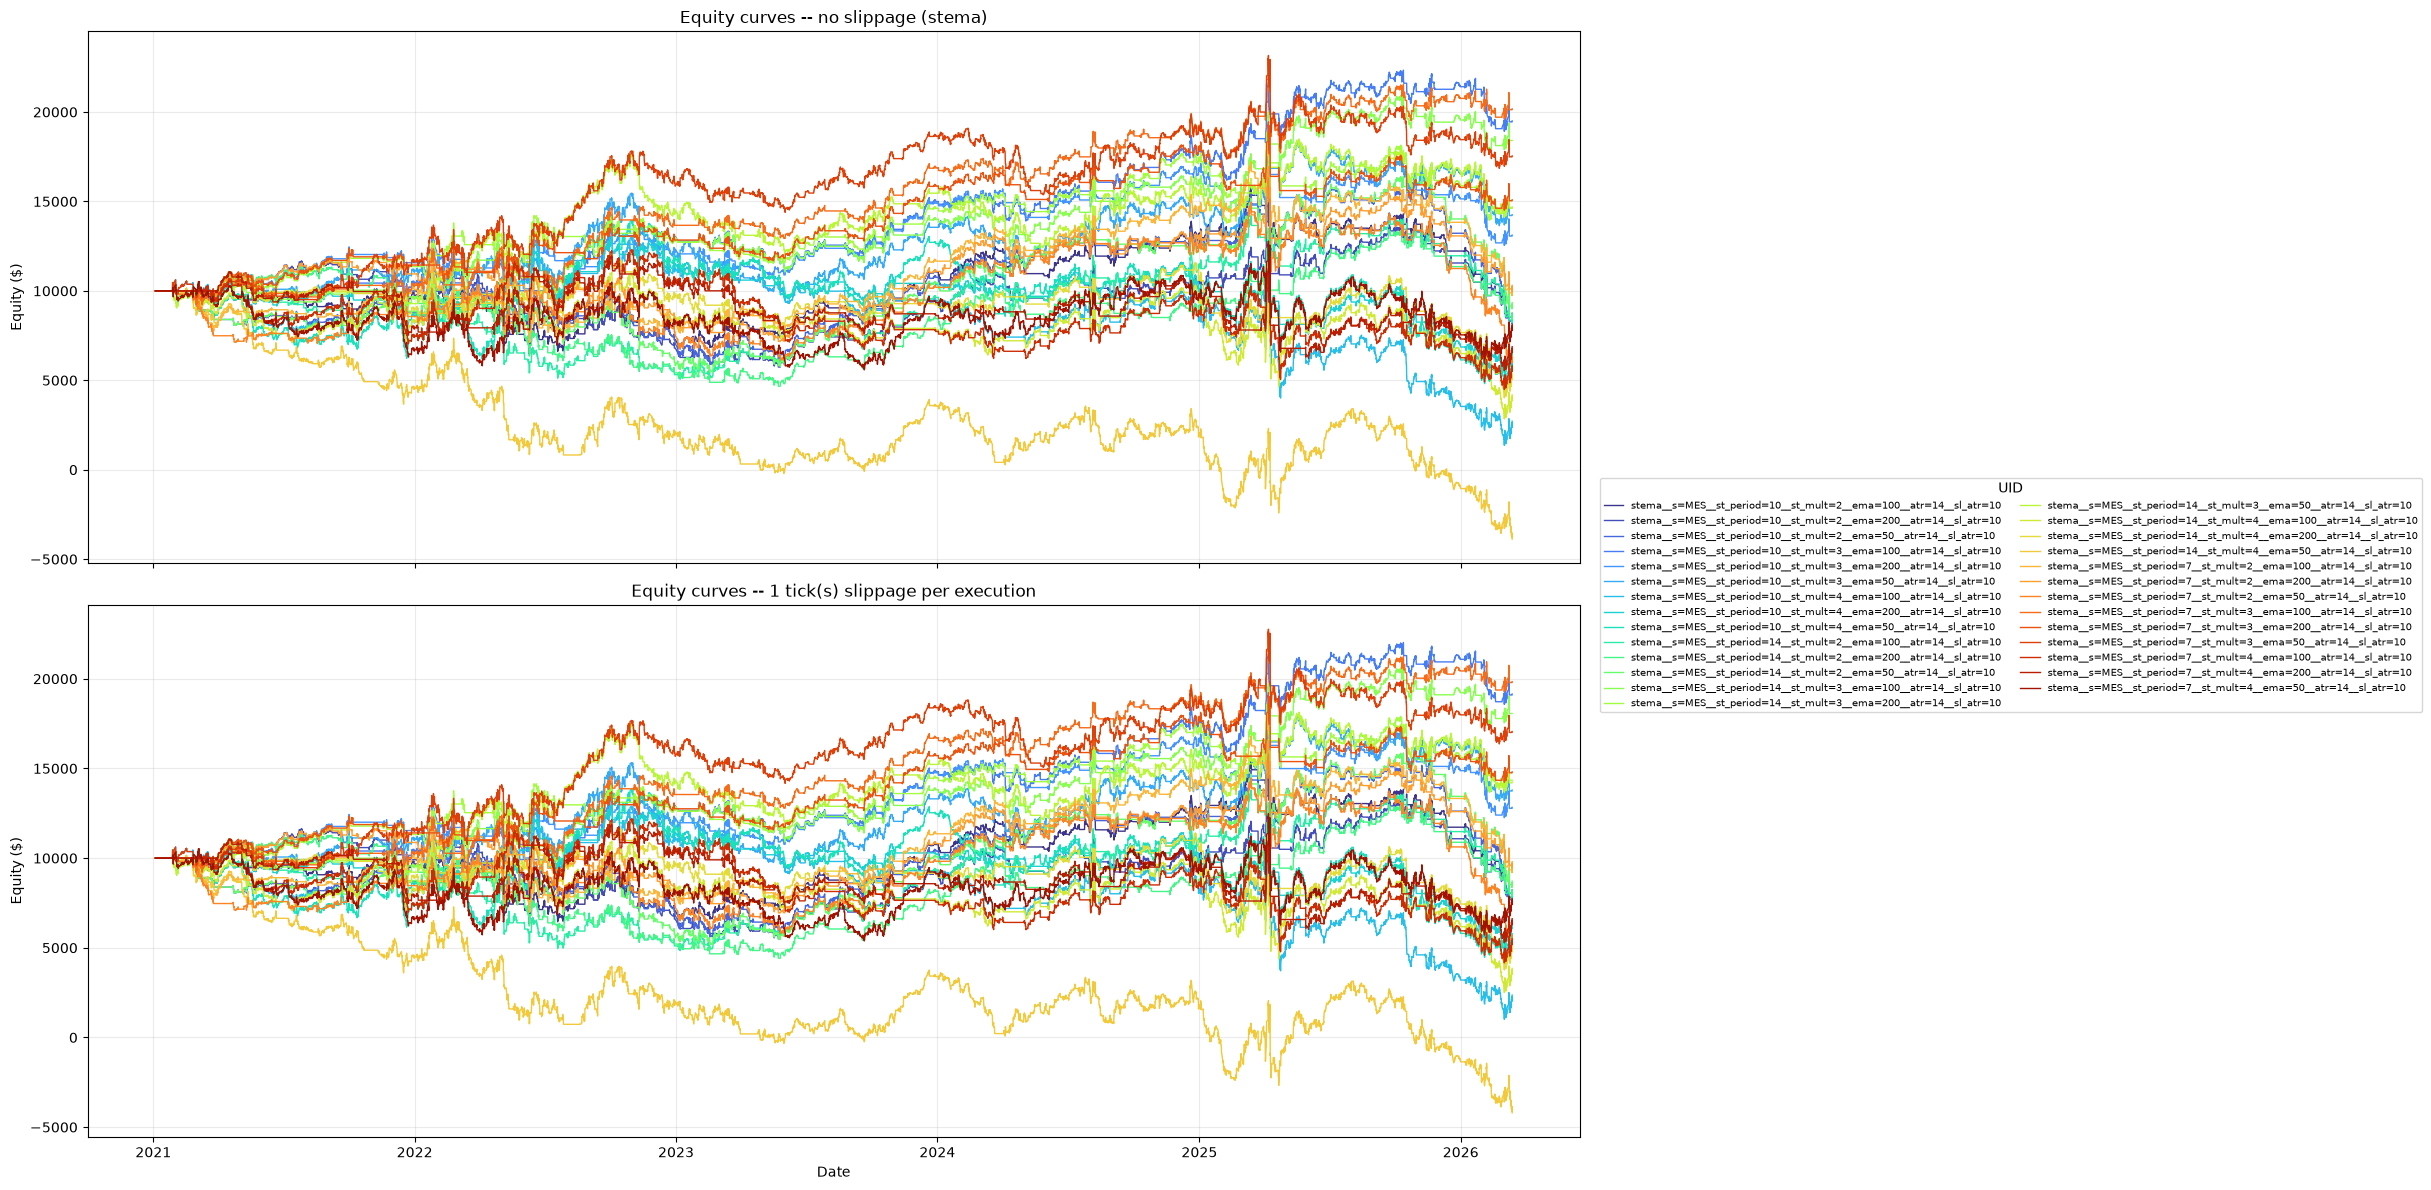

In [4]:
uids = sorted(equity_curves.keys())
colors = plt.cm.turbo(np.linspace(0.05, 0.95, max(len(uids), 1)))
color_by_uid = dict(zip(uids, colors))

figure, (raw_axis, slip_axis) = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(16, 12),
    sharex=True,
)

for uid in uids:
    color = color_by_uid[uid]

    raw = equity_curves[uid]["no_slippage"]
    raw_axis.plot(raw["timestamp"], raw["equity"], label=uid, linewidth=1.0, color=color)

    slipped = equity_curves[uid]["slippage"]
    slip_axis.plot(slipped["timestamp"], slipped["equity"], label=uid, linewidth=1.0, color=color)

raw_axis.set_title(f"Equity curves -- no slippage ({RESULTS_DIR.name})")
raw_axis.set_ylabel("Equity ($)")
raw_axis.grid(alpha=0.25)

slip_axis.set_title(f"Equity curves -- {SLIPPAGE_TICKS:g} tick(s) slippage per execution")
slip_axis.set_ylabel("Equity ($)")
slip_axis.set_xlabel("Date")
slip_axis.grid(alpha=0.25)

handles, labels = raw_axis.get_legend_handles_labels()
figure.legend(
    handles, labels,
    loc="center left",
    bbox_to_anchor=(1.0, 0.5),
    fontsize=7,
    ncol=1 if len(uids) <= 20 else 2,
    title="UID",
)

figure.tight_layout()
plt.show()